# NLLB-LID on NusaX-Senti
Tujuan: Validasi apakah NLLB-LID bisa diandalkan sebagai evaluator untuk mengukur Linguistic Purity Rate pada data sintetis nanti.

In [10]:
import fasttext
import fasttext.FastText
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from pathlib import Path
from collections import Counter

# Fix NumPy 2.x compatibility issue with fasttext
# fasttext uses np.array(obj, copy=False) which is deprecated in NumPy 2.x
_original_predict = fasttext.FastText._FastText.predict

def _patched_predict(self, text, k=1, threshold=0.0, on_unicode_error="strict"):
    if isinstance(text, list):
        all_labels, all_probs = [], []
        for t in text:
            l, p = _patched_predict(self, t, k, threshold, on_unicode_error)
            all_labels.append(l)
            all_probs.append(p)
        return all_labels, all_probs
    else:
        pairs = self.f.predict(text, k, threshold, on_unicode_error)
        if pairs:
            probs, labels = zip(*pairs)
        else:
            probs, labels = ([], ())
        return labels, np.asarray(probs)

fasttext.FastText._FastText.predict = _patched_predict

In [11]:
# Download NLLB-LID model dari HuggingFace
model_path = hf_hub_download(
    repo_id="cis-lmu/glotlid",
    filename="model.bin"
)
print(f"Model downloaded to: {model_path}")

# Load model
model = fasttext.load_model(model_path)

Model downloaded to: C:\Users\micha\.cache\huggingface\hub\models--cis-lmu--glotlid\snapshots\85cd6716494360367b75f642b5bc78667605d0b4\model.bin


In [12]:
labels, scores = model.predict("Sian bagasan roha do hami mandok horas tu hamu sude.", k=3)
labels, scores

(('__label__akb_Latn', '__label__bbc_Latn', '__label__dtp_Latn'),
 array([9.95751381e-01, 4.26859735e-03, 1.00081797e-05]))

In [13]:
# Semua bahasa NusaX-Senti
# GlotLID menggunakan format: __label__<iso639-3>_<script>
TARGET_LANGS = {
    "ace": "__label__ace_Latn",  # Acehnese
    "ban": "__label__ban_Latn",  # Balinese
    "bbc": "__label__bbc_Latn",  # Toba Batak
    "bjn": "__label__bjn_Latn",  # Banjarese
    "bug": "__label__bug_Latn",  # Buginese
    "eng": "__label__eng_Latn",  # English
    "ind": "__label__ind_Latn",  # Indonesian
    "jav": "__label__jav_Latn",  # Javanese
    "mad": "__label__mad_Latn",  # Madurese
    "min": "__label__min_Latn",  # Minangkabau
    "nij": "__label__nij_Latn",  # Ngaju
    "sun": "__label__sun_Latn",  # Sundanese
}

DATA_DIR = Path("../data/nusax_senti")
SPLITS = ["train", "valid", "test"]

In [14]:
def predict_language(text: str, k: int = 3):
    # Newlines break fasttext predictions
    clean_text = text.replace("\n", " ").strip()
    if not clean_text:
        return [], []
    labels, scores = model.predict(clean_text, k=k)
    return list(labels), list(scores)


def evaluate_nllb_on_nusax(lang_code: str, split: str = "train"):
    expected_label = TARGET_LANGS[lang_code]
    csv_path = DATA_DIR / lang_code / f"{split}.csv"
    df = pd.read_csv(csv_path)
    
    results = []
    for _, row in df.iterrows():
        text = str(row["text"])
        labels, scores = predict_language(text, k=3)
        
        top1_label = labels[0] if labels else ""
        top1_score = scores[0] if scores else 0.0
        is_correct = (top1_label == expected_label)
        
        # Cek apakah bahasa target ada di top-3
        in_top3 = expected_label in labels
        
        results.append({
            "id": row["id"],
            "text": text[:80] + "..." if len(text) > 80 else text,
            "sentiment": row["label"],
            "expected": expected_label,
            "predicted": top1_label,
            "confidence": round(top1_score, 4),
            "correct_top1": is_correct,
            "in_top3": in_top3,
            # Top-3 untuk analisis
            "top3_labels": str(labels),
            "top3_scores": str([round(s, 4) for s in scores]),
        })
    
    return pd.DataFrame(results)

## Validasi NLLB-LID pada Data NusaX Asli

Jalankan NLLB-LID pada **semua split** (train, valid, test) untuk ketiga bahasa target.
Ini untuk membuktikan bahwa NLLB-LID bisa diandalkan sebagai evaluator otomatis.

In [15]:
# Jalankan evaluasi untuk semua bahasa dan semua split
all_results = {}
summary_rows = []

for lang_code in TARGET_LANGS:
    for split in SPLITS:
        key = f"{lang_code}_{split}"
        print(f"Evaluating {lang_code} ({split})...", end=" ")
        
        df_result = evaluate_nllb_on_nusax(lang_code, split)
        all_results[key] = df_result
        
        n_total = len(df_result)
        n_correct_top1 = df_result["correct_top1"].sum()
        n_in_top3 = df_result["in_top3"].sum()
        avg_confidence = df_result["confidence"].mean()
        
        acc_top1 = n_correct_top1 / n_total * 100
        acc_top3 = n_in_top3 / n_total * 100
        
        summary_rows.append({
            "Language": lang_code,
            "Split": split,
            "Total": n_total,
            "Top-1 Correct": n_correct_top1,
            "Top-1 Accuracy (%)": round(acc_top1, 2),
            "Top-3 Accuracy (%)": round(acc_top3, 2),
            "Avg Confidence": round(avg_confidence, 4),
        })
        
        print(f"Top-1: {acc_top1:.1f}% | Top-3: {acc_top3:.1f}% | Avg Conf: {avg_confidence:.4f}")

print("\nDone!")

Evaluating ace (train)... Top-1: 95.4% | Top-3: 99.0% | Avg Conf: 0.9509
Evaluating ace (valid)... Top-1: 97.0% | Top-3: 99.0% | Avg Conf: 0.9757
Evaluating ace (test)... Top-1: 93.5% | Top-3: 97.5% | Avg Conf: 0.9502
Evaluating ban (train)... Top-1: 83.0% | Top-3: 94.8% | Avg Conf: 0.8783
Evaluating ban (valid)... Top-1: 85.0% | Top-3: 97.0% | Avg Conf: 0.9201
Evaluating ban (test)... Top-1: 83.2% | Top-3: 93.8% | Avg Conf: 0.8801
Evaluating bbc (train)... Top-1: 91.0% | Top-3: 97.2% | Avg Conf: 0.9050
Evaluating bbc (valid)... Top-1: 92.0% | Top-3: 97.0% | Avg Conf: 0.8851
Evaluating bbc (test)... Top-1: 91.0% | Top-3: 95.8% | Avg Conf: 0.9198
Evaluating bjn (train)... Top-1: 95.0% | Top-3: 97.2% | Avg Conf: 0.9562
Evaluating bjn (valid)... Top-1: 97.0% | Top-3: 97.0% | Avg Conf: 0.9679
Evaluating bjn (test)... Top-1: 95.0% | Top-3: 97.2% | Avg Conf: 0.9633
Evaluating bug (train)... Top-1: 93.6% | Top-3: 98.2% | Avg Conf: 0.9440
Evaluating bug (valid)... Top-1: 97.0% | Top-3: 99.0% |

In [16]:
# Tabel ringkasan akurasi NLLB-LID
df_summary = pd.DataFrame(summary_rows)
print("=" * 80)
print("NLLB-LID VALIDATION SUMMARY ON NusaX-Senti (Native Speaker-Validated Data)")
print("=" * 80)
display(df_summary)

# Rata-rata per bahasa (gabungan semua split)
print("\n--- Rata-rata per Bahasa (semua split) ---")
avg_per_lang = df_summary.groupby("Language").agg({
    "Total": "sum",
    "Top-1 Correct": "sum",
    "Top-1 Accuracy (%)": "mean",
    "Top-3 Accuracy (%)": "mean",
    "Avg Confidence": "mean",
}).round(2)
display(avg_per_lang)

NLLB-LID VALIDATION SUMMARY ON NusaX-Senti (Native Speaker-Validated Data)


,Language,Split,Total,Top-1 Correct,Top-1 Accuracy (%),Top-3 Accuracy (%),Avg Confidence
0,ace,train,500,477,95.40,99.00,0.9509
1,ace,valid,100,97,97.00,99.00,0.9757
2,ace,test,400,374,93.50,97.50,0.9502
3,ban,train,500,415,83.00,94.80,0.8783
4,ban,valid,100,85,85.00,97.00,0.9201
5,ban,test,400,333,83.25,93.75,0.8801
6,bbc,train,500,455,91.00,97.20,0.9050
7,bbc,valid,100,92,92.00,97.00,0.8851
8,bbc,test,400,364,91.00,95.75,0.9198
9,bjn,train,500,475,95.00,97.20,0.9562



--- Rata-rata per Bahasa (semua split) ---


,Total,Top-1 Correct,Top-1 Accuracy (%),Top-3 Accuracy (%),Avg Confidence
Language,,,,,
ace,1000,948,95.30,98.50,0.96
ban,1000,833,83.75,95.18,0.89
bbc,1000,911,91.33,96.65,0.90
bjn,1000,952,95.67,97.15,0.96
bug,1000,941,94.87,98.65,0.95
eng,1000,973,98.05,99.65,0.97
ind,1000,721,72.00,98.80,0.81
jav,1000,939,94.47,98.38,0.95
mad,1000,973,97.77,99.33,0.98


## Analisis Error: Kalimat yang Salah Diprediksi

Penting untuk melihat kalimat mana yang NLLB-LID salah prediksi.
Ini membantu memahami limitasi tool dan menentukan threshold yang tepat.

In [17]:
# Analisis error per bahasa (pada train split)
for lang_code in TARGET_LANGS:
    df_result = all_results[f"{lang_code}_train"]
    errors = df_result[~df_result["correct_top1"]]
    
    print(f"\n{'='*80}")
    print(f"ERRORS for {lang_code.upper()} (train) - {len(errors)} misclassified out of {len(df_result)}")
    print(f"{'='*80}")
    
    if len(errors) == 0:
        print("No errors! Perfect accuracy.")
        continue
    
    # Distribusi: bahasa apa yang diprediksi sebagai gantinya?
    pred_dist = Counter(errors["predicted"].values)
    print(f"\nMispredicted as:")
    for label, count in pred_dist.most_common(10):
        lang_name = label.replace("__label__", "")
        print(f"  {lang_name}: {count} ({count/len(errors)*100:.1f}%)")
    
    # Tampilkan beberapa contoh error
    print(f"\nSample errors (max 10):")
    for _, row in errors.head(10).iterrows():
        pred_lang = row["predicted"].replace("__label__", "")
        print(f"  [{row['confidence']:.3f}] Predicted: {pred_lang} | Text: {row['text']}")


ERRORS for ACE (train) - 23 misclassified out of 500

Mispredicted as:
  bew_Latn: 10 (43.5%)
  sun_Latn: 4 (17.4%)
  mad_Latn: 1 (4.3%)
  ind_Latn: 1 (4.3%)
  ksh_Latn: 1 (4.3%)
  sdq_Latn: 1 (4.3%)
  zsm_Latn: 1 (4.3%)
  bjn_Latn: 1 (4.3%)
  zao_Latn: 1 (4.3%)
  bch_Latn: 1 (4.3%)

Sample errors (max 10):
  [0.587] Predicted: sun_Latn | Text: Peulayanan bus DAMRI cukop get
  [0.739] Predicted: bew_Latn | Text: Bu gureng thailand yum 35 ribee, polos, cit na suir ayam bacut. Seafoodjih hana.
  [0.830] Predicted: mad_Latn | Text: Wah sama lagee loen abang ban satnyoe, paket freedom loen hana abeh lom tapi ka ...
  [0.832] Predicted: bew_Latn | Text: Kualita tempatjih mengecewakan. Jioh dari eskalator, payah ta lewat jalan ubit-b...
  [0.693] Predicted: ind_Latn | Text: Bogor akan geu pimpin kelai oleh Bima Arya
  [0.578] Predicted: ksh_Latn | Text: Jih dijep susu ultramilk lam kulkah
  [0.865] Predicted: bew_Latn | Text: Setuju maken ji ek fase wajar menye tiket ji ek. Tapi, yum dasar 

## Analisis Confidence Distribution

Visualisasi distribusi confidence score untuk memahami seberapa "yakin" NLLB-LID
dalam mengenali setiap bahasa. Ini membantu menentukan threshold yang tepat untuk evaluasi data sintetis nanti.

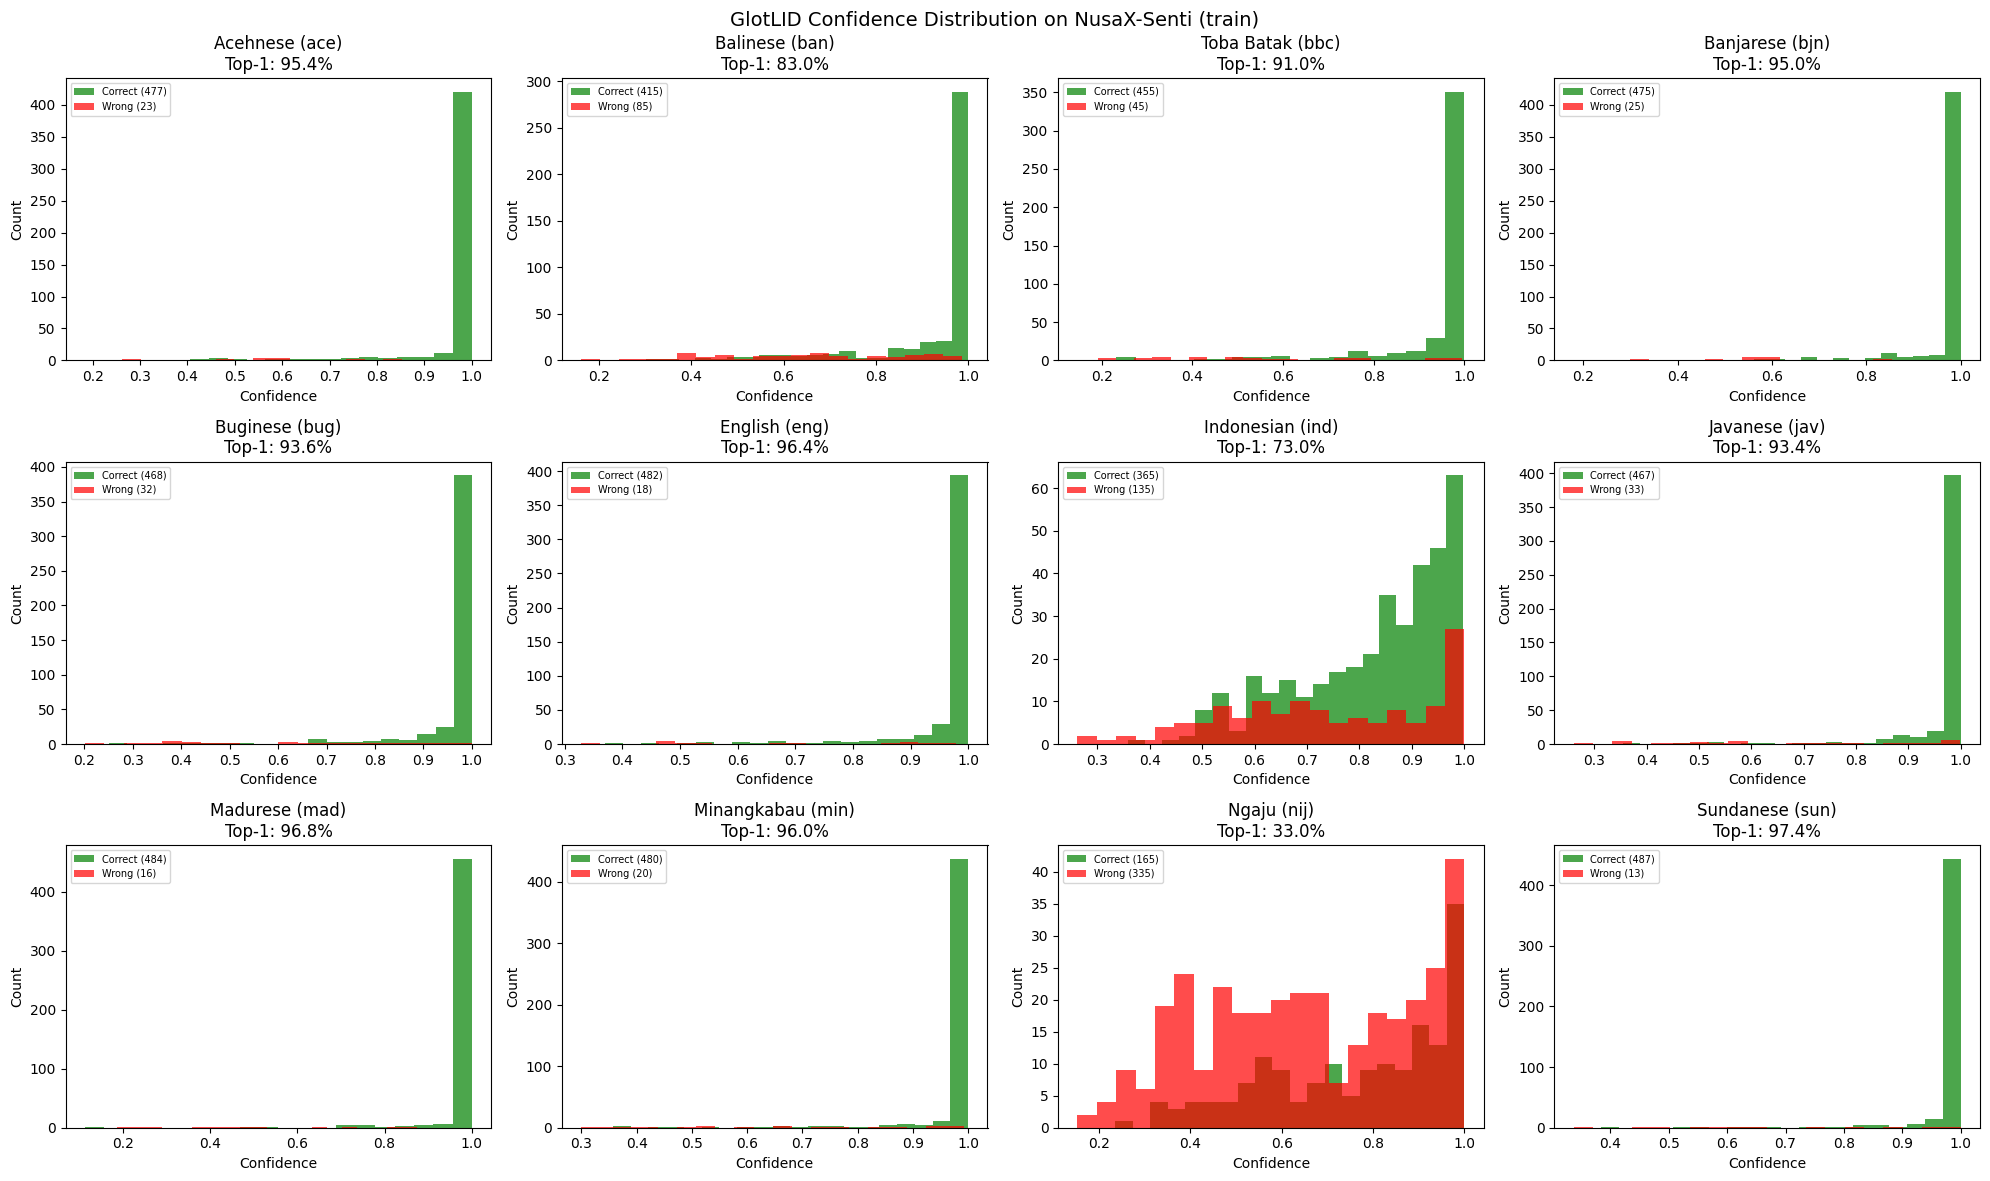

In [18]:
import matplotlib.pyplot as plt

lang_names = {
    "ace": "Acehnese", "ban": "Balinese", "bbc": "Toba Batak",
    "bjn": "Banjarese", "bug": "Buginese", "eng": "English",
    "ind": "Indonesian", "jav": "Javanese", "mad": "Madurese",
    "min": "Minangkabau", "nij": "Ngaju", "sun": "Sundanese",
}

n_langs = len(TARGET_LANGS)
cols = 4
rows = (n_langs + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for idx, lang_code in enumerate(TARGET_LANGS):
    df_result = all_results[f"{lang_code}_train"]
    ax = axes[idx]
    
    correct = df_result[df_result["correct_top1"]]["confidence"]
    wrong = df_result[~df_result["correct_top1"]]["confidence"]
    
    acc = len(correct) / len(df_result) * 100
    ax.hist(correct, bins=20, alpha=0.7, label=f"Correct ({len(correct)})", color="green")
    if len(wrong) > 0:
        ax.hist(wrong, bins=20, alpha=0.7, label=f"Wrong ({len(wrong)})", color="red")
    
    ax.set_title(f"{lang_names[lang_code]} ({lang_code})\nTop-1: {acc:.1f}%")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

plt.suptitle("GlotLID Confidence Distribution on NusaX-Senti (train)", fontsize=14)
plt.tight_layout()
plt.show()